
# 📊 Exploratory Data Analysis (EDA)

## Student Performance Dataset

Variables :

- student_id
- attendance_pct
- absence_hours
- homework_pct
- study_hours_per_week
- midterm_score
- informatique
- mathematique
- svt
- physique
- sport
- education_islamique
- francais
- arabe
- pass


In [53]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)

from IPython.display import display

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Dataset

In [54]:

df = pd.read_csv("data.csv", sep=";", encoding="utf-8")

# Clean column names and force numeric types
df.columns = df.columns.str.strip()
for col in df.columns:
    if col != "student_id":
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (4050, 15)
Columns: ['student_id', 'attendance_pct', 'absence_hours', 'homework_pct', 'study_hours_per_week', 'midterm_score', 'informatique', 'mathematique', 'svt', 'physique', 'sport', 'education_islamique', 'francais', 'arabe', 'pass']


,student_id,attendance_pct,absence_hours,homework_pct,study_hours_per_week,midterm_score,informatique,mathematique,svt,physique,sport,education_islamique,francais,arabe,pass
0,1,95.0,5,92.0,12,88.0,88.4,82.4,90.5,95.4,78.7,78.2,95.4,94.9,1
1,2,88.0,27,85.0,10,79.0,96.9,88.2,86.3,93.6,53.2,53.5,84.1,76.2,1
2,3,60.0,67,55.0,4,58.0,54.0,53.1,79.2,61.0,64.4,31.7,56.0,64.7,0
3,4,72.0,42,70.0,6,65.0,65.7,57.8,58.8,56.6,97.0,61.7,48.2,74.3,1
4,5,40.0,103,45.0,3,50.0,53.6,37.8,36.9,53.3,66.3,55.3,50.0,47.0,0


## 2. Dataset Overview

In [55]:

display(df.info())

display(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            4050 non-null   int64  
 1   attendance_pct        4050 non-null   float64
 2   absence_hours         4050 non-null   int64  
 3   homework_pct          4050 non-null   float64
 4   study_hours_per_week  4050 non-null   int64  
 5   midterm_score         4050 non-null   float64
 6   informatique          4050 non-null   float64
 7   mathematique          4050 non-null   float64
 8   svt                   4050 non-null   float64
 9   physique              4050 non-null   float64
 10  sport                 4050 non-null   float64
 11  education_islamique   4050 non-null   float64
 12  francais              4050 non-null   float64
 13  arabe                 4050 non-null   float64
 14  pass                  4050 non-null   int64  
dtypes: float64(11), int64

None

,student_id,attendance_pct,absence_hours,homework_pct,study_hours_per_week,midterm_score,informatique,mathematique,svt,physique,sport,education_islamique,francais,arabe,pass
count,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000
mean,2025.500000,70.590296,59.462963,65.911951,7.282963,63.106074,63.284642,63.567679,63.083086,63.493951,62.327506,62.364198,63.428025,63.299012,0.674074
std,1169.278624,20.144144,42.581884,20.952898,3.696825,18.770479,21.691111,20.719312,21.852249,21.454225,23.831905,24.846836,22.147784,22.879466,0.468778
min,1.000000,15.000000,0.000000,12.000000,1.000000,15.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0.000000
25%,1013.250000,52.800000,26.000000,50.800000,4.000000,45.700000,46.300000,47.300000,46.100000,46.200000,45.225000,43.800000,46.700000,46.300000,0.000000
50%,2025.500000,77.200000,49.000000,68.650000,8.000000,68.300000,66.250000,67.000000,65.800000,66.550000,63.600000,64.000000,65.900000,65.200000,1.000000
75%,3037.750000,86.100000,93.750000,82.275000,10.000000,78.200000,80.900000,79.600000,79.975000,80.000000,80.800000,82.800000,80.875000,81.300000,1.000000
max,4050.000000,100.000000,180.000000,100.000000,19.000000,99.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000


## 3. Missing Values

In [56]:

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing Count", ascending=False)


,Missing Count,Missing %
student_id,0,0.0
attendance_pct,0,0.0
absence_hours,0,0.0
homework_pct,0,0.0
study_hours_per_week,0,0.0
midterm_score,0,0.0
informatique,0,0.0
mathematique,0,0.0
svt,0,0.0
physique,0,0.0


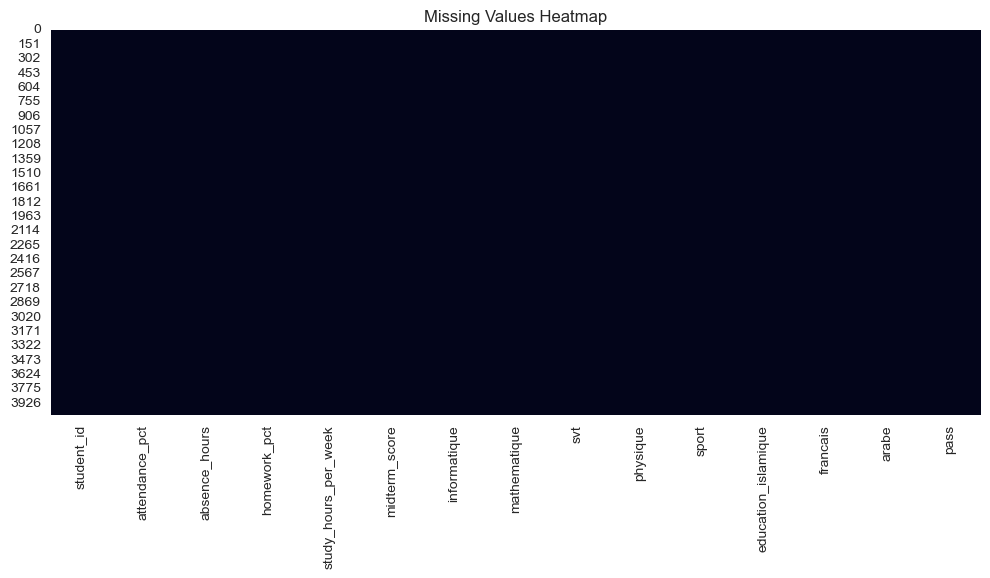

In [57]:

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


## 4. Target Variable Analysis

In [58]:

df["pass"].value_counts()


pass
1    2730
0    1320
Name: count, dtype: int64

## 5. Numerical Variables Distribution

In [59]:

num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in ["student_id", "pass"]:
    if col in num_cols:
        num_cols.remove(col)

num_cols


['attendance_pct',
 'absence_hours',
 'homework_pct',
 'study_hours_per_week',
 'midterm_score',
 'informatique',
 'mathematique',
 'svt',
 'physique',
 'sport',
 'education_islamique',
 'francais',
 'arabe']

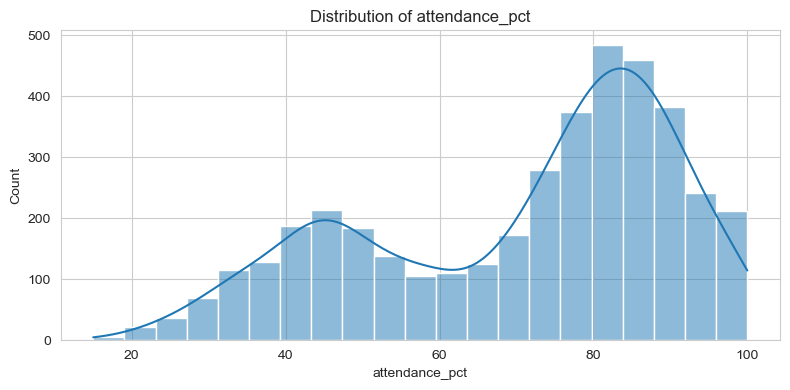

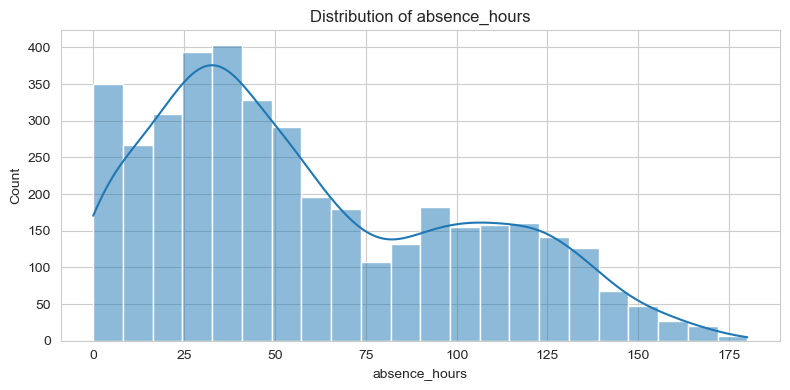

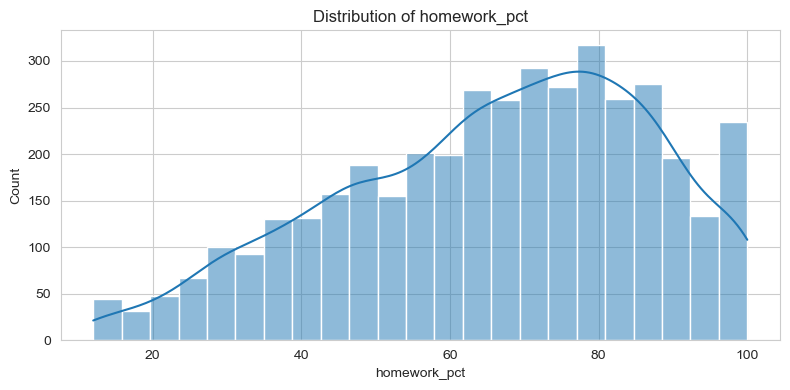

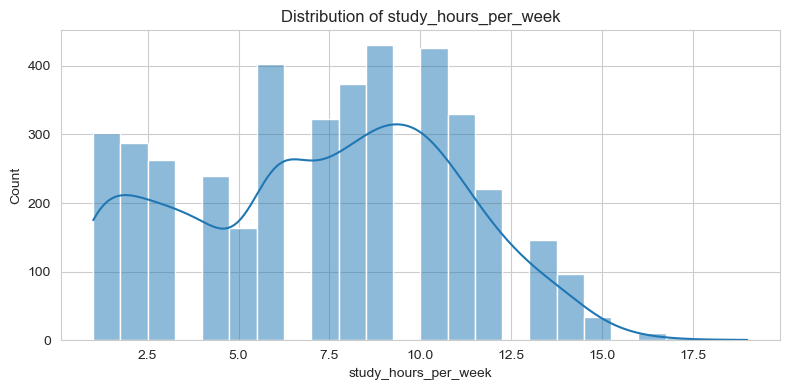

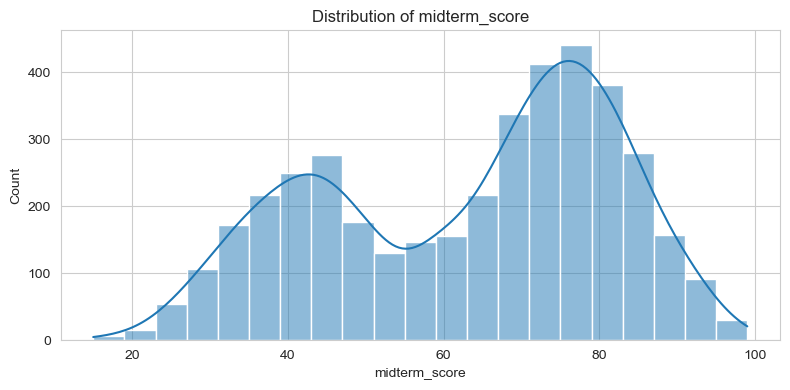

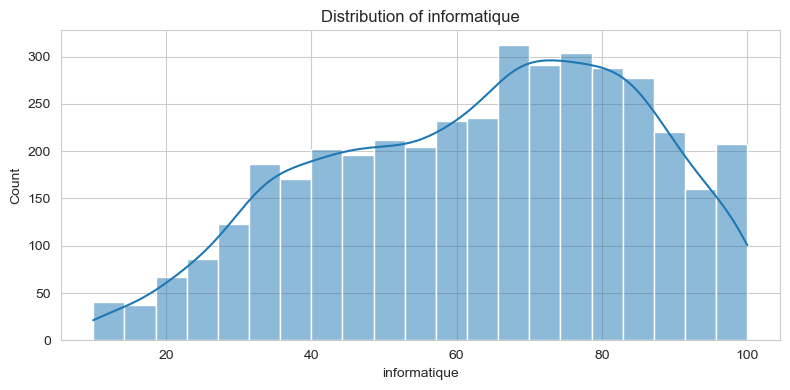

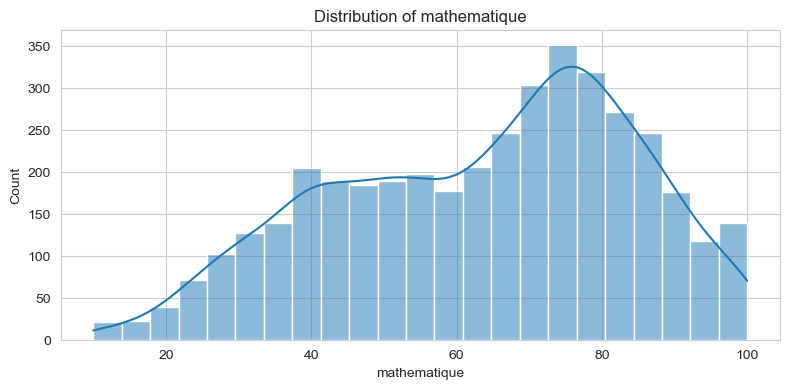

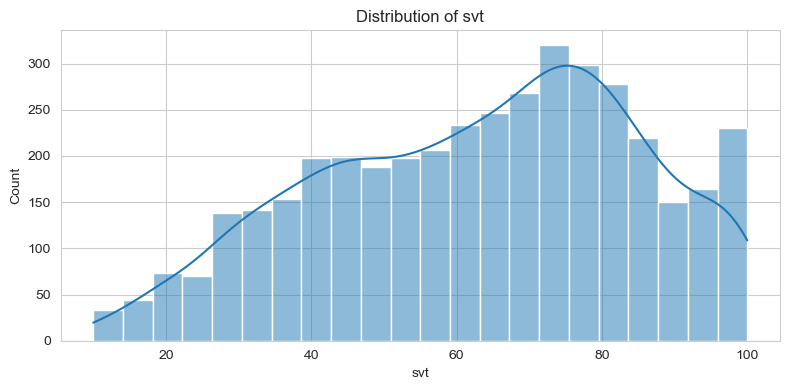

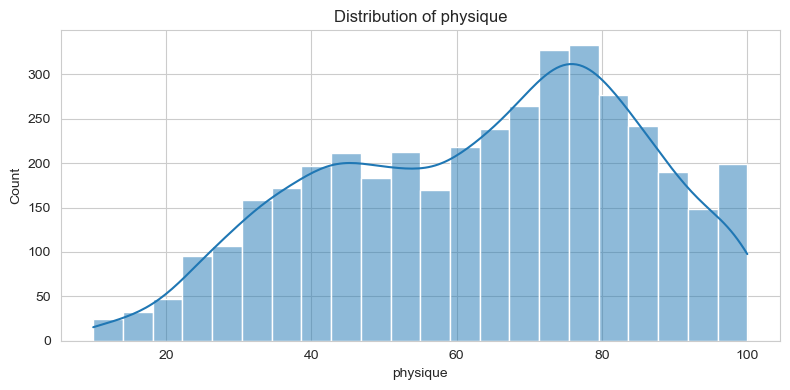

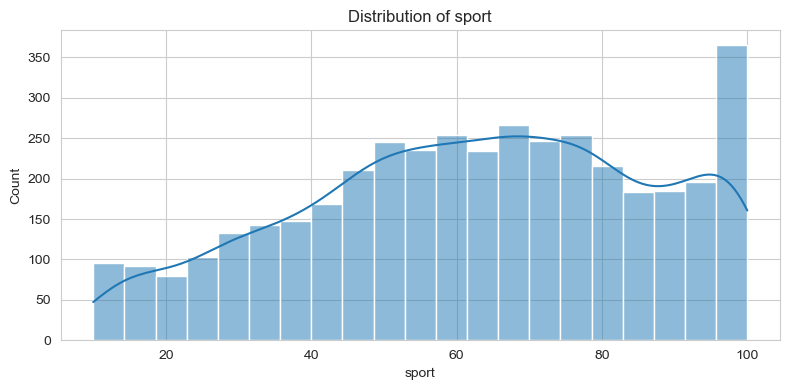

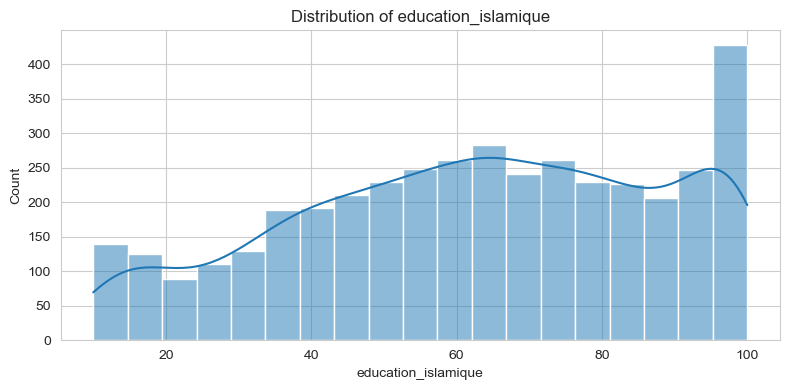

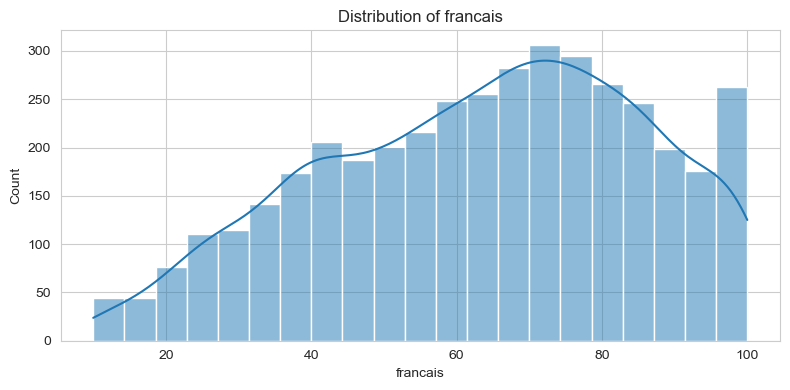

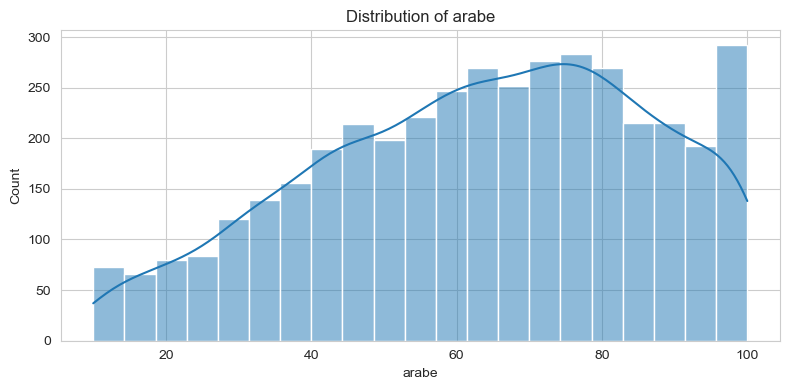

In [60]:

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## 6. Outlier Detection (IQR)

In [61]:

outlier_summary = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append([col, outliers])

pd.DataFrame(
    outlier_summary,
    columns=["Feature","Outliers"]
).sort_values("Outliers", ascending=False)


,Feature,Outliers
0,attendance_pct,0
1,absence_hours,0
2,homework_pct,0
3,study_hours_per_week,0
4,midterm_score,0
5,informatique,0
6,mathematique,0
7,svt,0
8,physique,0
9,sport,0


## 7. Correlation Analysis

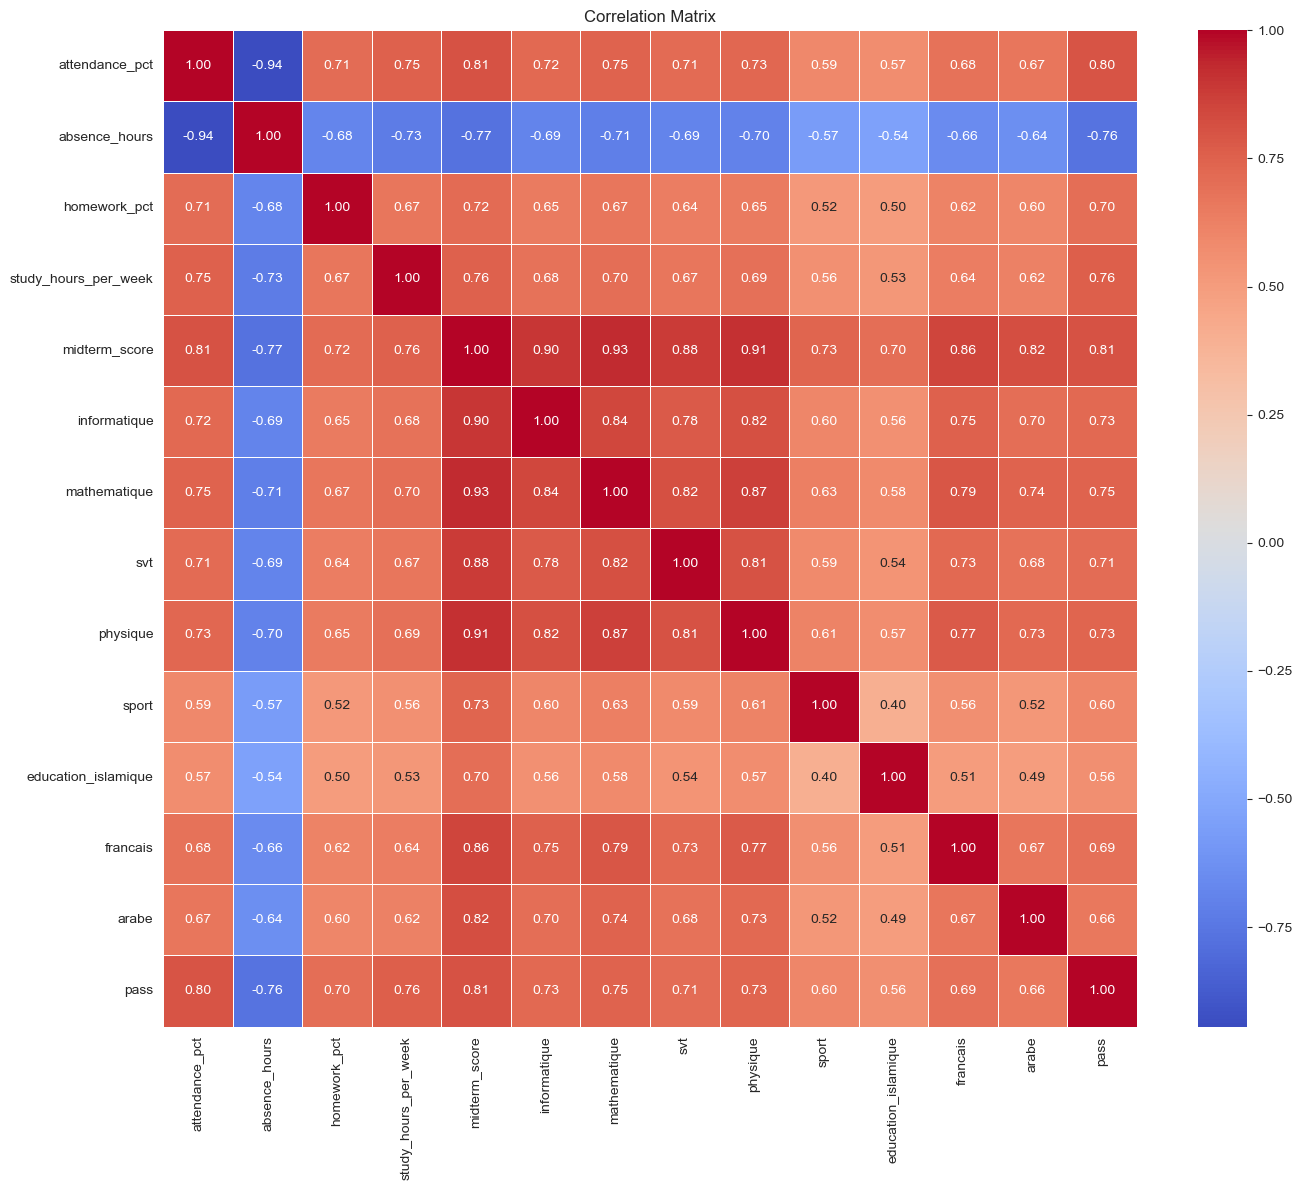

In [62]:

corr_cols = num_cols + ["pass"]
corr = df[corr_cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 13. Rapport d'Efficacité — Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    log_loss, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Prepare data ---
feature_cols = num_cols  # all numeric cols except student_id and pass
X = df[feature_cols].dropna()
y = df.loc[X.index, "pass"]

# --- Train/Test split (80/20) ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Pipeline: Scaler + Logistic Regression ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

# --- K-Fold Cross Validation (k=5) ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

j_train_list, j_cv_list, acc_list = [], [], []

for train_idx, val_idx in kf.split(X_train, y_train):
    Xtr, Xval = X_train.iloc[train_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipe.fit(Xtr, ytr)
    j_train_list.append(log_loss(ytr,  pipe.predict_proba(Xtr)))
    j_cv_list.append(log_loss(yval, pipe.predict_proba(Xval)))
    acc_list.append(accuracy_score(yval, pipe.predict(Xval)))

j_train_kfolds = np.mean(j_train_list)
j_cv_kfolds    = np.mean(j_cv_list)
accuracy_cv    = np.mean(acc_list)
pourcentage_erreur_cv = (1 - accuracy_cv) * 100

# --- Train final model on full train set, evaluate on test set ---
pipe.fit(X_train, y_train)
j_global = log_loss(y, pipe.predict_proba(X))
y_pred   = pipe.predict(X_test)
formatted_report = classification_report(y_test, y_pred,
    target_names=["Fail (0)", "Pass (1)"])

# --- Print Report ---
print(" RAPPORT D'EFFICACITÉ DE L'ALGORITHME (LOGISTIC REGRESSION)")
print("============================================================")
print(f"🎯 J GLOBAL  (Fonction de Coût Totale  - LogLoss) : {j_global:.4f}")
print(f"🔹 J_train   (Coût d'Entraînement Moyen - LogLoss) : {j_train_kfolds:.4f}")
print(f"🔹 J_CV      (Coût de Validation Croisée - LogLoss) : {j_cv_kfolds:.4f}")
print("------------------------------------------------------------")
print(f"📈 Taux de Précision Globale (CV Accuracy)          : {accuracy_cv * 100:.2f}%")
print(f"❌ Pourcentage d'Erreur Générale de l'IA             : {pourcentage_erreur_cv:.2f}%")
print("============================================================")
print(" MATRICE ET MÉTRIQUES DÉTAILLÉES (SUR LE JEU DE TEST EXTÉRIEUR) :")
print(formatted_report)


 RAPPORT D'EFFICACITÉ DE L'ALGORITHME (LOGISTIC REGRESSION)
🎯 J GLOBAL  (Fonction de Coût Totale  - LogLoss) : 0.1749
🔹 J_train   (Coût d'Entraînement Moyen - LogLoss) : 0.1729
🔹 J_CV      (Coût de Validation Croisée - LogLoss) : 0.1783
------------------------------------------------------------
📈 Taux de Précision Globale (CV Accuracy)          : 91.23%
❌ Pourcentage d'Erreur Générale de l'IA             : 8.77%
 MATRICE ET MÉTRIQUES DÉTAILLÉES (SUR LE JEU DE TEST EXTÉRIEUR) :
              precision    recall  f1-score   support

    Fail (0)       0.88      0.85      0.86       264
    Pass (1)       0.93      0.94      0.94       546

    accuracy                           0.91       810
   macro avg       0.90      0.90      0.90       810
weighted avg       0.91      0.91      0.91       810



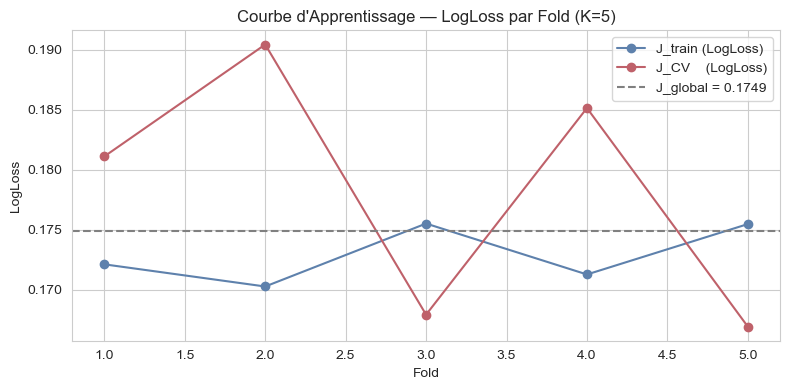

In [64]:
# --- Learning Curve (J_train vs J_CV) ---
fold_nums = list(range(1, len(j_train_list) + 1))

plt.figure(figsize=(8, 4))
plt.plot(fold_nums, j_train_list, "o-", label="J_train (LogLoss)", color="#5e81ac")
plt.plot(fold_nums, j_cv_list,    "o-", label="J_CV    (LogLoss)", color="#bf616a")
plt.axhline(j_global, linestyle="--", color="gray", label=f"J_global = {j_global:.4f}")
plt.xlabel("Fold")
plt.ylabel("LogLoss")
plt.title("Courbe d'Apprentissage — LogLoss par Fold (K=5)")
plt.legend()
plt.tight_layout()
plt.show()
